In [ ]:
rb = pd.read_csv('FantasyPros_Fantasy_Football_Projections_RB.csv', skiprows=[1])
wr = pd.read_csv('FantasyPros_Fantasy_Football_Projections_WR.csv', skiprows=[1])
te = pd.read_csv('FantasyPros_Fantasy_Football_Projections_TE.csv', skiprows=[1])

print("RB columns:", list(rb.columns))
print("WR columns:", list(wr.columns))
print("TE columns:", list(te.columns))

NameError: name 'pd' is not defined

In [ ]:
import pandas as pd

In [ ]:
import pandas as pd

rb = pd.read_csv('FantasyPros_Fantasy_Football_Projections_RB.csv', skiprows=[1])
wr = pd.read_csv('FantasyPros_Fantasy_Football_Projections_WR.csv', skiprows=[1])
te = pd.read_csv('FantasyPros_Fantasy_Football_Projections_TE.csv', skiprows=[1])

print("RB columns:", list(rb.columns))
print("WR columns:", list(wr.columns))
print("TE columns:", list(te.columns))

FileNotFoundError: [Errno 2] No such file or directory: 'FantasyPros_Fantasy_Football_Projections_RB.csv'

In [ ]:
import os
print(os.getcwd())
print(os.listdir())

/content
['.config', 'sample_data']


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving FantasyPros_Fantasy_Football_Projections_QB.csv to FantasyPros_Fantasy_Football_Projections_QB.csv
Saving FantasyPros_Fantasy_Football_Projections_RB.csv to FantasyPros_Fantasy_Football_Projections_RB.csv
Saving FantasyPros_Fantasy_Football_Projections_TE.csv to FantasyPros_Fantasy_Football_Projections_TE.csv
Saving FantasyPros_Fantasy_Football_Projections_WR.csv to FantasyPros_Fantasy_Football_Projections_WR.csv


In [ ]:
import pandas as pd

rb = pd.read_csv('FantasyPros_Fantasy_Football_Projections_RB.csv', skiprows=[1])
wr = pd.read_csv('FantasyPros_Fantasy_Football_Projections_WR.csv', skiprows=[1])
te = pd.read_csv('FantasyPros_Fantasy_Football_Projections_TE.csv', skiprows=[1])

print("RB columns:", list(rb.columns))
print("WR columns:", list(wr.columns))
print("TE columns:", list(te.columns))

RB columns: ['Player', 'Team', 'ATT', 'YDS', 'TDS', 'REC', 'YDS.1', 'TDS.1', 'FL', 'FPTS']
WR columns: ['Player', 'Team', 'REC', 'YDS', 'TDS', 'ATT', 'YDS.1', 'TDS.1', 'FL', 'FPTS']
TE columns: ['Player', 'Team', 'REC', 'YDS', 'TDS', 'FL', 'FPTS']


In [ ]:
rb = rb.rename(columns={
    'ATT': 'RUSH_ATT', 'YDS': 'RUSH_YDS', 'TDS': 'RUSH_TDS',
    'REC': 'REC', 'YDS.1': 'REC_YDS', 'TDS.1': 'REC_TDS'
})

wr = wr.rename(columns={
    'REC': 'REC', 'YDS': 'REC_YDS', 'TDS': 'REC_TDS',
    'ATT': 'RUSH_ATT', 'YDS.1': 'RUSH_YDS', 'TDS.1': 'RUSH_TDS'
})

print("RB columns:", list(rb.columns))
print("WR columns:", list(wr.columns))

RB columns: ['Player', 'Team', 'RUSH_ATT', 'RUSH_YDS', 'RUSH_TDS', 'REC', 'REC_YDS', 'REC_TDS', 'FL', 'FPTS']
WR columns: ['Player', 'Team', 'REC', 'REC_YDS', 'REC_TDS', 'RUSH_ATT', 'RUSH_YDS', 'RUSH_TDS', 'FL', 'FPTS']


In [ ]:
qb = pd.read_csv('FantasyPros_Fantasy_Football_Projections_QB.csv', skiprows=[1])

qb['POS'] = 'QB'
rb['POS'] = 'RB'
wr['POS'] = 'WR'
te['POS'] = 'TE'

print(qb.shape, rb.shape, wr.shape, te.shape)

(84, 13) (133, 11) (192, 11) (116, 8)


In [ ]:
combined = pd.concat([qb, rb, wr, te], ignore_index=True)

print(combined.shape)
combined.head()

(525, 19)


,Player,Team,ATT,CMP,YDS,TDS,INTS,ATT.1,YDS.1,TDS.1,FL,FPTS,POS,RUSH_ATT,RUSH_YDS,RUSH_TDS,REC,REC_YDS,REC_TDS
0,Josh Allen,BUF,491.6,333.0,"3,814.0",27.4,11.2,118.1,585.2,11.8,4.1,372.2,QB,NaN,NaN,NaN,NaN,NaN,NaN
1,Drake Maye,NE,503.9,346.0,"4,062.7",28.3,10.4,100.3,505.5,3.7,5.6,326.9,QB,NaN,NaN,NaN,NaN,NaN,NaN
2,Jayden Daniels,WAS,495.4,324.8,"3,712.7",24.1,10.6,130.0,685.6,4.7,2.8,325.5,QB,NaN,NaN,NaN,NaN,NaN,NaN
3,Lamar Jackson,BAL,449.3,291.9,"3,654.7",28.3,9.6,118.7,640.3,3.2,4.2,325.0,QB,NaN,NaN,NaN,NaN,NaN,NaN
4,Jalen Hurts,PHI,488.0,317.2,"3,571.9",24.2,7.4,111.8,461.1,8.4,4.0,320.6,QB,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
combined['FPTS'] = pd.to_numeric(combined['FPTS'], errors='coerce')

print(combined['FPTS'].isna().sum(), "missing FPTS values")
combined[['Player', 'Team', 'POS', 'FPTS']].sort_values('FPTS', ascending=False).head(10)

8 missing FPTS values


,Player,Team,POS,FPTS
0,Josh Allen,BUF,QB,372.2
84,Jahmyr Gibbs,DET,RB,337.2
85,Bijan Robinson,ATL,RB,332.2
1,Drake Maye,NE,QB,326.9
2,Jayden Daniels,WAS,QB,325.5
3,Lamar Jackson,BAL,QB,325.0
4,Jalen Hurts,PHI,QB,320.6
5,Jaxson Dart,NYG,QB,311.8
6,Joe Burrow,CIN,QB,310.9
7,Brock Purdy,SF,QB,307.4


In [ ]:
combined[combined['FPTS'].isna()][['Player', 'Team', 'POS']]

,Player,Team,POS
82,NaN,NaN,QB
83,NaN,NaN,QB
215,NaN,NaN,RB
216,NaN,NaN,RB
407,NaN,NaN,WR
408,NaN,NaN,WR
523,NaN,NaN,TE
524,NaN,NaN,TE


In [ ]:
combined = combined.dropna(subset=['Player'])

print(combined.shape)
print(combined['FPTS'].isna().sum(), "missing FPTS values remaining")

(517, 19)
0 missing FPTS values remaining


In [ ]:
def get_replacement_value(df, pos, rank):
    pos_df = df[df['POS'] == pos].sort_values('FPTS', ascending=False)
    return pos_df.iloc[rank - 1]['FPTS']

replacement = {
    'QB': get_replacement_value(combined, 'QB', 20),
    'RB': get_replacement_value(combined, 'RB', 31),
    'WR': get_replacement_value(combined, 'WR', 31),
    'TE': get_replacement_value(combined, 'TE', 14),
}

print(replacement)

{'QB': np.float64(274.5), 'RB': np.float64(167.5), 'WR': np.float64(163.7), 'TE': np.float64(131.2)}


In [ ]:
combined['VORP'] = combined.apply(
    lambda row: row['FPTS'] - replacement[row['POS']], axis=1
)

combined[['Player', 'Team', 'POS', 'FPTS', 'VORP']].sort_values('VORP', ascending=False).head(20)

,Player,Team,POS,FPTS,VORP
84,Jahmyr Gibbs,DET,RB,337.2,169.7
85,Bijan Robinson,ATL,RB,332.2,164.7
86,Christian McCaffrey,SF,RB,295.7,128.2
87,Jonathan Taylor,IND,RB,289.9,122.4
217,Puka Nacua,LAR,WR,281.3,117.6
218,Ja'Marr Chase,CIN,WR,275.4,111.7
219,Jaxon Smith-Njigba,SEA,WR,268.6,104.9
0,Josh Allen,BUF,QB,372.2,97.7
220,Amon-Ra St. Brown,DET,WR,261.1,97.4
88,Derrick Henry,BAL,RB,264.2,96.7


In [ ]:
combined.to_csv('vorp_draft_board.csv', index=False)

from google.colab import files
files.download('vorp_draft_board.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def assign_rounds(df, pos, teams=12):
    pos_df = df[df['POS'] == pos].sort_values('VORP', ascending=False).reset_index(drop=True)
    pos_df['Round'] = (pos_df.index // teams) + 1
    return pos_df

qb_rounds = assign_rounds(combined, 'QB')
rb_rounds = assign_rounds(combined, 'RB')
wr_rounds = assign_rounds(combined, 'WR')
te_rounds = assign_rounds(combined, 'TE')

qb_rounds[['Player', 'POS', 'VORP', 'Round']].head(15)

,Player,POS,VORP,Round
0,Josh Allen,QB,97.7,1
1,Drake Maye,QB,52.4,1
2,Jayden Daniels,QB,51.0,1
3,Lamar Jackson,QB,50.5,1
4,Jalen Hurts,QB,46.1,1
5,Jaxson Dart,QB,37.3,1
6,Joe Burrow,QB,36.4,1
7,Brock Purdy,QB,32.9,1
8,Dak Prescott,QB,31.6,1
9,Trevor Lawrence,QB,29.5,1


In [ ]:
def avg_vorp_by_round(df, pos_label):
    return df.groupby('Round')['VORP'].mean().reset_index().assign(POS=pos_label)

avg_qb = avg_vorp_by_round(qb_rounds, 'QB')
avg_rb = avg_vorp_by_round(rb_rounds, 'RB')
avg_wr = avg_vorp_by_round(wr_rounds, 'WR')
avg_te = avg_vorp_by_round(te_rounds, 'TE')

round_avg = pd.concat([avg_qb, avg_rb, avg_wr, avg_te], ignore_index=True)
round_avg.head(10)

,Round,VORP,POS
0,1,43.350000,QB
1,2,6.016667,QB
2,3,-114.258333,QB
3,4,-259.391667,QB
4,5,-263.866667,QB
5,6,-264.875000,QB
6,7,-269.230000,QB
7,1,103.091667,RB
8,2,44.050000,RB
9,3,-3.683333,RB


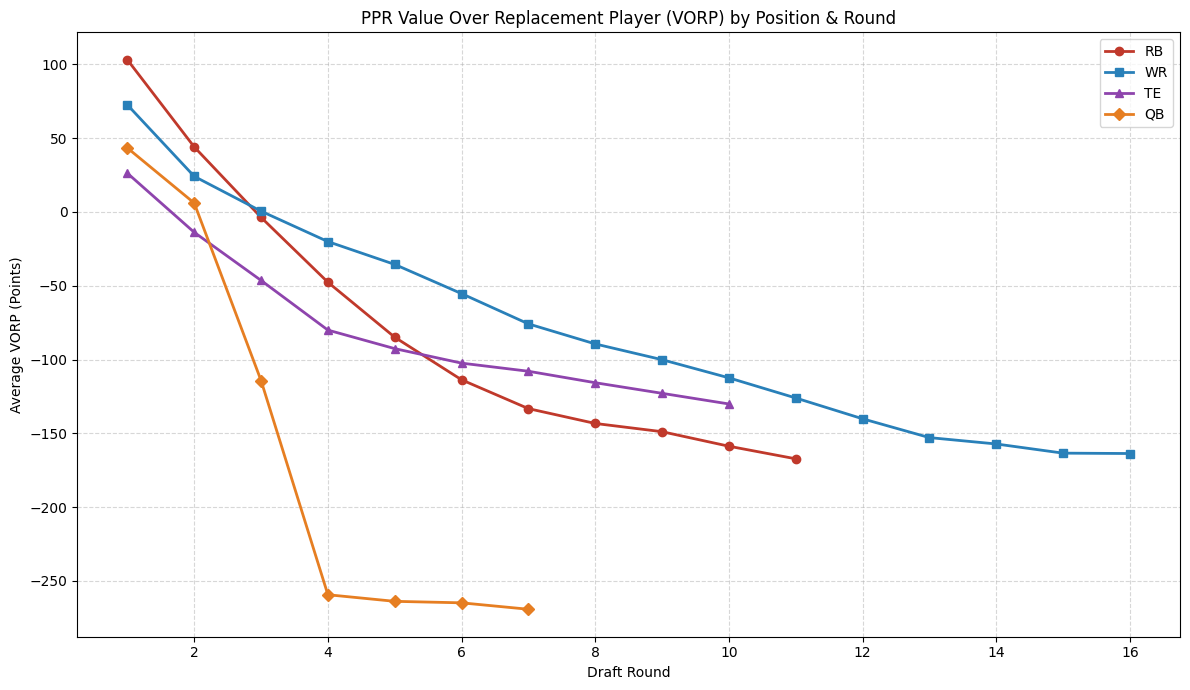

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))

colors = {'RB': '#c0392b', 'WR': '#2980b9', 'TE': '#8e44ad', 'QB': '#e67e22'}
markers = {'RB': 'o', 'WR': 's', 'TE': '^', 'QB': 'D'}

for pos in ['RB', 'WR', 'TE', 'QB']:
    pos_data = round_avg[round_avg['POS'] == pos].sort_values('Round')
    ax.plot(pos_data['Round'], pos_data['VORP'],
            marker=markers[pos], color=colors[pos], label=pos, linewidth=2)

ax.set_xlabel('Draft Round')
ax.set_ylabel('Average VORP (Points)')
ax.set_title('PPR Value Over Replacement Player (VORP) by Position & Round')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()